# Synthetic BES V3.1 — portable inference & evaluation

This notebook is the **portable shared-data version** of the earlier qualitative/quantitative inference notebook.

It assumes that all shared files are in **one directory**:

```text
shared_folder/
├── synthetic_bes_v3_1_shared.h5
├── synthetic_bes_v3_1_shared_model.pt
├── train_synthetic_bes_v3_1_shared.py
└── inference_synthetic_bes_v3_1_shared.ipynb
```

There are **no user-specific absolute paths**.

The shared HDF5 contains only event-level:

- `input`: `(T, 8, 8)` BES signals
- `target`: `(T,)` actual ELM labels

under `/train`, `/val`, and `/test`.

This notebook reconstructs the forecast evaluation windows from the actual ELM onset/end, reproduces validation/test ROC analysis, computes event-wise AUC, and shows 5 representative full-event time-series cases.

In [1]:
from pathlib import Path
from contextlib import nullcontext
import json
import math
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, total=None, desc=None, leave=True, **kwargs):
        return iterable if iterable is not None else range(total or 0)

try:
    from IPython.display import display
except Exception:
    display = print

## 1. Portable configuration

In [2]:
# Run this notebook from the shared directory.
BASE_DIR = Path(".").resolve()

DATA_PATH = BASE_DIR / "synthetic_bes_v3_1_shared.h5"
CHECKPOINT_PATH = BASE_DIR / "synthetic_bes_v3_1_temporal_spatial_elm_map_8x8_to_2x2_ddp.pt"
OUT_DIR = BASE_DIR / "inference_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GPU_ID = 0
DEVICE = torch.device(
    f"cuda:{GPU_ID}" if torch.cuda.is_available() else "cpu"
)

INFERENCE_BATCH_SIZE = 2048
CENTER_STRIDE_SAMPLES = 20
N_QUALITATIVE_EVENTS = 5

print("BASE_DIR       :", BASE_DIR)
print("DATA_PATH      :", DATA_PATH)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("DEVICE         :", DEVICE)

if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"{CHECKPOINT_PATH} not found. Run train_synthetic_bes_v3_1_shared.py first."
    )

BASE_DIR       : /global/cfs/cdirs/m3586/sjoung/synthetic_bes_v3_1_elm_ddp
DATA_PATH      : /global/cfs/cdirs/m3586/sjoung/synthetic_bes_v3_1_elm_ddp/synthetic_bes_v3_1_shared.h5
CHECKPOINT_PATH: /global/cfs/cdirs/m3586/sjoung/synthetic_bes_v3_1_elm_ddp/synthetic_bes_v3_1_temporal_spatial_elm_map_8x8_to_2x2_ddp.pt
DEVICE         : cuda:0


## 2. Model definition and checkpoint loading

In [3]:
class TemporalSpatialELMMapNet(nn.Module):
    def __init__(
        self,
        input_time=320,
        grid_shape=(8, 8),
        temporal_channels=(8, 16, 32),
        spatial_channels=(64, 64),
        temporal_kernel_size=7,
        dropout=0.10,
    ):
        super().__init__()
        self.input_time = int(input_time)
        self.grid_shape = tuple(grid_shape)

        t_layers = []
        in_ch = 1
        pad = temporal_kernel_size // 2
        for out_ch in temporal_channels:
            t_layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size=temporal_kernel_size, padding=pad),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(2),
            ]
            if dropout > 0:
                t_layers.append(nn.Dropout(dropout))
            in_ch = out_ch
        self.temporal_net = nn.Sequential(*t_layers)

        s_layers = []
        in_ch = temporal_channels[-1]
        for out_ch in spatial_channels:
            s_layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ]
            if dropout > 0:
                s_layers.append(nn.Dropout2d(dropout))
            in_ch = out_ch
        self.spatial_net = nn.Sequential(*s_layers)
        self.out_head = nn.Conv2d(spatial_channels[-1], 1, kernel_size=1)

    def forward(self, x):
        B, T, H, W = x.shape
        if T != self.input_time or (H, W) != self.grid_shape:
            raise ValueError(
                f"Expected (B,{self.input_time},{self.grid_shape[0]},{self.grid_shape[1]}), "
                f"got {tuple(x.shape)}"
            )
        z = x.permute(0, 2, 3, 1).contiguous().view(B * H * W, 1, T)
        z = self.temporal_net(z).mean(dim=-1)
        Ct = z.shape[1]
        z = z.view(B, H, W, Ct).permute(0, 3, 1, 2).contiguous()
        z = self.spatial_net(z)
        return self.out_head(z)


def torch_load_compat(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


ckpt = torch_load_compat(CHECKPOINT_PATH, map_location="cpu")
cfg = ckpt.get("config", {})

model_kwargs = dict(
    cfg.get(
        "model_kwargs",
        dict(input_time=320, grid_shape=(8, 8)),
    )
)
for key in ("grid_shape", "temporal_channels", "spatial_channels"):
    if key in model_kwargs:
        model_kwargs[key] = tuple(model_kwargs[key])

model = TemporalSpatialELMMapNet(**model_kwargs)
state = ckpt["model_state_dict"]

if len(state) and all(str(k).startswith("module.") for k in state):
    state = {str(k)[7:]: v for k, v in state.items()}

model.load_state_dict(state, strict=True)
model.to(DEVICE)
model.eval()

WINDOW_SIZE = int(cfg.get("input_time", 320))
DECISION_THRESHOLD = float(cfg.get("decision_threshold", 0.5))
WINDOW_STRIDE = int(cfg.get("window_stride", 8))

LABEL_RANGES = cfg.get(
    "label_ranges",
    [
        dict(name="far_pre",       reference="onset", dt0_ms=-3.7, dt1_ms=-3.1, target=0.0, max_windows=32),
        dict(name="early_pre_elm", reference="onset", dt0_ms=-2.8, dt1_ms=-2.2, target=0.5, max_windows=64),
        dict(name="pre_elm",       reference="onset", dt0_ms=-1.8, dt1_ms=-0.5, target=1.0, max_windows=64),
        dict(name="recovery",      reference="end",   dt0_ms=+0.5, dt1_ms=+1.4, target=0.0, max_windows=32),
    ],
)

with h5py.File(DATA_PATH, "r") as f:
    SAMPLE_DT_US = float(f.attrs.get("sample_dt_us", cfg.get("sample_dt_us", 1.0)))
    print("Shared H5 format:", f.attrs.get("format", "unknown"))
    print("sample_dt_us:", SAMPLE_DT_US)
    print("preprocess_mode:", f.attrs.get("preprocess_mode", "unknown"))
    print("events:", {s: len(f[s]) for s in ("train", "val", "test")})

print("WINDOW_SIZE:", WINDOW_SIZE)
print("WINDOW_STRIDE:", WINDOW_STRIDE)
print("DECISION_THRESHOLD:", DECISION_THRESHOLD)
display(pd.DataFrame(LABEL_RANGES))

Shared H5 format: synthetic_bes_v3_1_shared
sample_dt_us: 1.0
preprocess_mode: raw
events: {'train': 700, 'val': 150, 'test': 150}
WINDOW_SIZE: 320
WINDOW_STRIDE: 8
DECISION_THRESHOLD: 0.6049443483352661


,name,reference,dt0_ms,dt1_ms,target,max_windows
0,far_pre,onset,-3.7,-3.1,0.0,32
1,early_pre_elm,onset,-2.8,-2.2,0.5,64
2,pre_elm,onset,-1.8,-0.5,1.0,64
3,recovery,end,0.5,1.4,0.0,32


## 3. Shared-H5 event/window utilities

In [4]:
def list_events(split="test"):
    with h5py.File(DATA_PATH, "r") as f:
        return sorted(f[split].keys())


def load_event(split, event_name):
    with h5py.File(DATA_PATH, "r") as f:
        g = f[split][event_name]
        x = np.asarray(g["input"], dtype=np.float32)
        y = np.asarray(g["target"], dtype=np.uint8)
    return x, y


def detect_elm_bounds(target):
    idx = np.flatnonzero(np.asarray(target) > 0)
    if len(idx) == 0:
        raise ValueError("No actual ELM samples in target.")
    return int(idx[0]), int(idx[-1] + 1)


def relative_time_ms(target):
    onset, end = detect_elm_bounds(target)
    t = (np.arange(len(target)) - onset) * SAMPLE_DT_US / 1000.0
    elm_end_ms = (end - onset) * SAMPLE_DT_US / 1000.0
    return t, onset, end, elm_end_ms


def ms_to_samples(dt_ms):
    return float(dt_ms) * 1000.0 / SAMPLE_DT_US


def candidate_centers(target, reference_index, dt0_ms, dt1_ms, stride):
    T = len(target)
    half_left = WINDOW_SIZE // 2
    half_right = WINDOW_SIZE - half_left

    a = reference_index + ms_to_samples(dt0_ms)
    b = reference_index + ms_to_samples(dt1_ms)
    lo = int(np.ceil(min(a, b) - 1e-12))
    hi = int(np.floor(max(a, b) + 1e-12))

    lo = max(lo, half_left)
    hi = min(hi, T - half_right)

    if hi < lo:
        return np.asarray([], dtype=np.int64)

    return np.arange(lo, hi + 1, int(stride), dtype=np.int64)


def forecast_eval_centers(target, split, event_number, seed=1234):
    onset, end = detect_elm_bounds(target)

    # Match the original trainer's per-split RNG sequence by using one RNG
    # outside this function in evaluate_split(). This helper only creates
    # candidate centers.
    rows = []
    for spec in LABEL_RANGES:
        ref = onset if spec["reference"] == "onset" else end
        centers = candidate_centers(
            target,
            ref,
            spec["dt0_ms"],
            spec["dt1_ms"],
            WINDOW_STRIDE,
        )
        rows.append((spec, centers))
    return rows


def make_window_batch(x_event, centers):
    X = np.empty(
        (len(centers), WINDOW_SIZE, 8, 8),
        dtype=np.float32,
    )
    half_left = WINDOW_SIZE // 2
    for i, c in enumerate(centers):
        s = int(c - half_left)
        X[i] = x_event[s:s + WINDOW_SIZE]
    return X


def autocast_context():
    if DEVICE.type == "cuda" and torch.cuda.is_bf16_supported():
        return torch.autocast("cuda", dtype=torch.bfloat16)
    return nullcontext()


def score_centers(x_event, centers, batch_size=INFERENCE_BATCH_SIZE):
    if len(centers) == 0:
        return np.asarray([], dtype=float), np.empty((0, 1, 2, 2), dtype=np.float32)

    score_parts = []
    map_parts = []

    with torch.inference_mode():
        for i in range(0, len(centers), batch_size):
            c = centers[i:i + batch_size]
            xb = torch.from_numpy(make_window_batch(x_event, c)).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            with autocast_context():
                pm = torch.sigmoid(model(xb))
            pm = pm.float().cpu().numpy()
            map_parts.append(pm)
            score_parts.append(pm.mean(axis=(1, 2, 3)))

    return np.concatenate(score_parts), np.concatenate(map_parts)

## 4. Reconstruct the exact validation/test forecast-window evaluation

The shared H5 does not store duplicated 320-sample windows. Instead, this section reconstructs the same forecast ranges from each event's `target`.

In [5]:
def evaluate_split(split, seed=1234):
    event_names = list_events(split)
    rng = np.random.default_rng(
        seed + {"train": 0, "val": 1, "test": 2}[split]
    )

    rows = []

    for event_number, event_name in enumerate(
        tqdm(event_names, desc=f"evaluate {split}")
    ):
        x_event, y_event = load_event(split, event_name)
        onset, end = detect_elm_bounds(y_event)

        for spec, centers in forecast_eval_centers(
            y_event, split, event_number, seed=seed
        ):
            maxw = spec.get("max_windows", None)
            if maxw is not None and len(centers) > int(maxw):
                centers = np.sort(
                    rng.choice(centers, size=int(maxw), replace=False)
                )

            scores, _ = score_centers(x_event, centers)

            for c, score in zip(centers, scores):
                rows.append(
                    dict(
                        split=split,
                        event=event_name,
                        center=int(c),
                        dt_from_on_ms=float(
                            (c - onset) * SAMPLE_DT_US / 1000.0
                        ),
                        target=float(spec["target"]),
                        range_name=str(spec["name"]),
                        score=float(score),
                    )
                )

    return pd.DataFrame(rows)


val_df = evaluate_split("val")
test_df = evaluate_split("test")

print("Validation windows:", len(val_df))
print("Test windows:", len(test_df))
print("Test events:", test_df["event"].nunique())

display(pd.crosstab(test_df["range_name"], test_df["target"], margins=True))

val_df.to_csv(OUT_DIR / "validation_window_scores.csv", index=False)
test_df.to_csv(OUT_DIR / "test_window_scores.csv", index=False)

evaluate val:   0%|          | 0/150 [00:00<?, ?it/s]

evaluate test:   0%|          | 0/150 [00:00<?, ?it/s]

Validation windows: 28800
Test windows: 28800
Test events: 150


target,0.0,0.5,1.0,All
range_name,,,,
early_pre_elm,0,9600,0,9600
far_pre,4800,0,0,4800
pre_elm,0,0,9600,9600
recovery,4800,0,0,4800
All,9600,9600,9600,28800


## 5. Pooled ROC and threshold metrics

,split,auc,threshold,tp,tn,fp,fn,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,validation,0.9442,0.6049,7930,9255,345,1670,0.8951,0.8951,0.9583,0.8260,0.9641,0.8873
1,test,0.9387,0.6049,7948,9194,406,1652,0.8928,0.8928,0.9514,0.8279,0.9577,0.8854


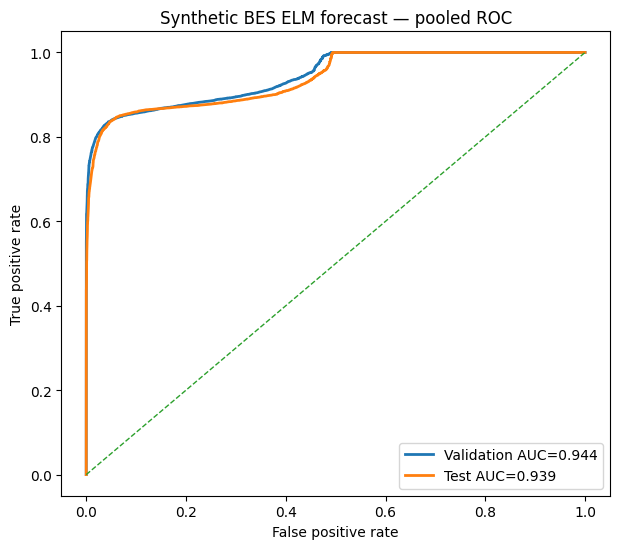

In [6]:
def auc_trapezoid(y, x):
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))


def roc_curve_numpy(y_cont, scores):
    y_cont = np.asarray(y_cont, dtype=float)
    scores = np.asarray(scores, dtype=float)

    mask = (
        np.isfinite(y_cont)
        & np.isfinite(scores)
        & (~np.isclose(y_cont, 0.5))
    )
    y = (y_cont[mask] >= 0.75).astype(int)
    s = scores[mask]

    thresholds = np.r_[np.inf, np.sort(np.unique(s))[::-1], -np.inf]
    P = max(int(np.sum(y == 1)), 1)
    N = max(int(np.sum(y == 0)), 1)
    tpr, fpr = [], []

    for th in thresholds:
        pred = s >= th
        tpr.append(np.sum(pred & (y == 1)) / P)
        fpr.append(np.sum(pred & (y == 0)) / N)

    fpr = np.asarray(fpr)
    tpr = np.asarray(tpr)
    order = np.argsort(fpr, kind="stable")
    return fpr[order], tpr[order], thresholds[order], auc_trapezoid(tpr[order], fpr[order])


def binary_metrics(y_cont, scores, threshold):
    y_cont = np.asarray(y_cont, dtype=float)
    scores = np.asarray(scores, dtype=float)
    mask = (
        np.isfinite(y_cont)
        & np.isfinite(scores)
        & (~np.isclose(y_cont, 0.5))
    )
    y = (y_cont[mask] >= 0.75).astype(int)
    pred = (scores[mask] >= threshold).astype(int)

    tp = int(np.sum((y == 1) & (pred == 1)))
    tn = int(np.sum((y == 0) & (pred == 0)))
    fp = int(np.sum((y == 0) & (pred == 1)))
    fn = int(np.sum((y == 1) & (pred == 0)))

    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    precision = tp / max(tp + fp, 1)
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    return dict(
        threshold=float(threshold),
        tp=tp, tn=tn, fp=fp, fn=fn,
        accuracy=float(accuracy),
        balanced_accuracy=float(0.5 * (recall + specificity)),
        precision=float(precision),
        recall=float(recall),
        specificity=float(specificity),
        f1=float(f1),
    )


val_fpr, val_tpr, _, val_auc = roc_curve_numpy(
    val_df["target"], val_df["score"]
)
test_fpr, test_tpr, _, test_auc = roc_curve_numpy(
    test_df["target"], test_df["score"]
)

val_metrics = binary_metrics(
    val_df["target"], val_df["score"], DECISION_THRESHOLD
)
test_metrics = binary_metrics(
    test_df["target"], test_df["score"], DECISION_THRESHOLD
)

metrics_table = pd.DataFrame(
    [
        {"split": "validation", "auc": val_auc, **val_metrics},
        {"split": "test", "auc": test_auc, **test_metrics},
    ]
)
display(metrics_table.round(4))
metrics_table.to_csv(OUT_DIR / "pooled_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(6.3, 5.6))
ax.plot(val_fpr, val_tpr, lw=2, label=f"Validation AUC={val_auc:.3f}")
ax.plot(test_fpr, test_tpr, lw=2, label=f"Test AUC={test_auc:.3f}")
ax.plot([0, 1], [0, 1], "--", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Synthetic BES ELM forecast — pooled ROC")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT_DIR / "roc_pooled_validation_test.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Event-wise test ROC and representative 5-case selection

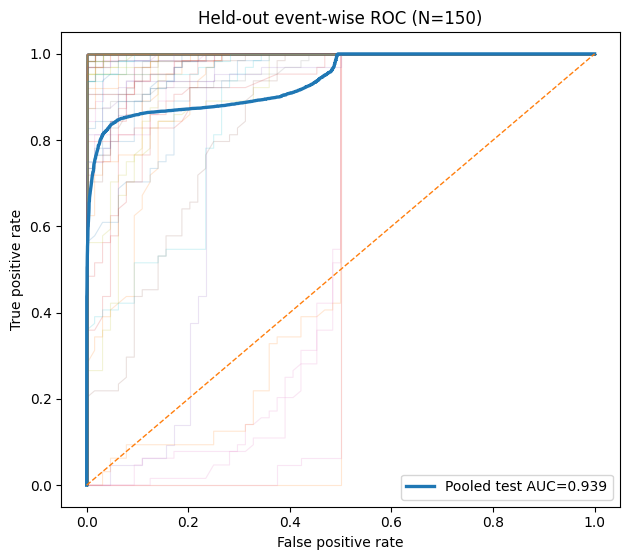

,event_auc
count,150.0000
mean,0.9761
std,0.0855
min,0.5000
5%,0.8884
25%,0.9981
50%,1.0000
75%,1.0000
95%,1.0000
max,1.0000


Selected representative events:


,event,auc,n_windows
0,event_000091,0.500,192
37,event_000121,0.998,192
74,event_000048,1.000,192
112,event_000109,1.000,192
149,event_000148,1.000,192


In [7]:
event_rows = []
event_curves = []

for event_name, g in test_df.groupby("event", sort=True):
    try:
        fpr, tpr, _, auc = roc_curve_numpy(g["target"], g["score"])
    except Exception:
        continue

    event_rows.append(
        dict(
            event=event_name,
            auc=float(auc),
            n_windows=len(g),
        )
    )
    event_curves.append((event_name, fpr, tpr, auc))

event_metrics = pd.DataFrame(event_rows).sort_values("auc").reset_index(drop=True)
event_metrics.to_csv(OUT_DIR / "test_eventwise_auc.csv", index=False)

fig, ax = plt.subplots(figsize=(6.4, 5.7))
for event_name, fpr, tpr, auc in event_curves:
    ax.plot(fpr, tpr, lw=0.8, alpha=0.18)

ax.plot(test_fpr, test_tpr, lw=2.4, label=f"Pooled test AUC={test_auc:.3f}")
ax.plot([0, 1], [0, 1], "--", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"Held-out event-wise ROC (N={len(event_metrics)})")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT_DIR / "roc_test_eventwise.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    event_metrics["auc"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .to_frame("event_auc")
    .round(4)
)

if len(event_metrics) <= N_QUALITATIVE_EVENTS:
    selected_events = event_metrics.copy()
else:
    qpos = np.linspace(0, len(event_metrics) - 1, N_QUALITATIVE_EVENTS)
    idx = np.unique(np.round(qpos).astype(int))
    selected_events = event_metrics.iloc[idx].copy()

selected_event_names = selected_events["event"].tolist()

print("Selected representative events:")
display(selected_events.round(4))

## 7. Full-event sliding inference for the representative 5 cases

The time axis is reconstructed only from:

- the first `target==1` sample = exact ELM onset;
- the H5 root attribute `sample_dt_us`.

No original `time` dataset is required.

In [8]:
def valid_sliding_centers(T, stride=CENTER_STRIDE_SAMPLES):
    half_left = WINDOW_SIZE // 2
    half_right = WINDOW_SIZE - half_left
    return np.arange(
        half_left,
        T - half_right + 1,
        int(stride),
        dtype=np.int64,
    )


def run_full_event(event_name):
    x, y = load_event("test", event_name)
    t_ms, onset, end, elm_end_ms = relative_time_ms(y)

    centers = valid_sliding_centers(len(y))
    scores, prob_maps = score_centers(x, centers)

    half_left = WINDOW_SIZE // 2
    half_right = WINDOW_SIZE - half_left
    starts = centers - half_left
    ends = centers + half_right
    overlaps_elm = (starts < end) & (ends > onset)

    result = pd.DataFrame(
        {
            "center_index": centers,
            "dt_from_elm_onset_ms": (
                (centers - onset) * SAMPLE_DT_US / 1000.0
            ),
            "score": scores,
            "predicted_positive": scores >= DECISION_THRESHOLD,
            "window_overlaps_actual_elm": overlaps_elm,
            "p00": prob_maps[:, 0, 0, 0],
            "p01": prob_maps[:, 0, 0, 1],
            "p10": prob_maps[:, 0, 1, 0],
            "p11": prob_maps[:, 0, 1, 1],
        }
    )

    return dict(
        event=event_name,
        input=x,
        target=y,
        time_ms=t_ms,
        onset=onset,
        end=end,
        elm_end_ms=elm_end_ms,
        result=result,
    )


qualitative = {}
for i, event_name in enumerate(selected_event_names, start=1):
    print(f"[{i}/{len(selected_event_names)}] {event_name}")
    q = run_full_event(event_name)
    qualitative[event_name] = q
    q["result"].to_csv(
        OUT_DIR / f"qualitative_{i:02d}_{event_name}_sliding.csv",
        index=False,
    )

[1/5] event_000091
[2/5] event_000121
[3/5] event_000048
[4/5] event_000109
[5/5] event_000148


## 8. Detailed qualitative time-series figures

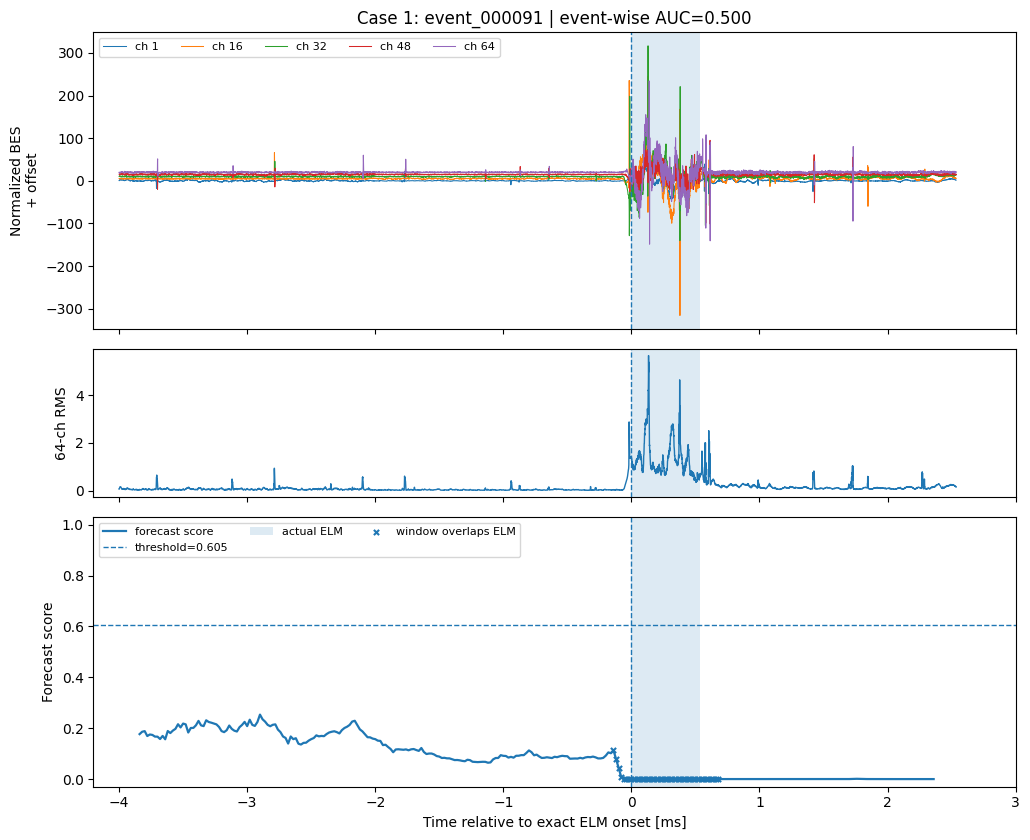

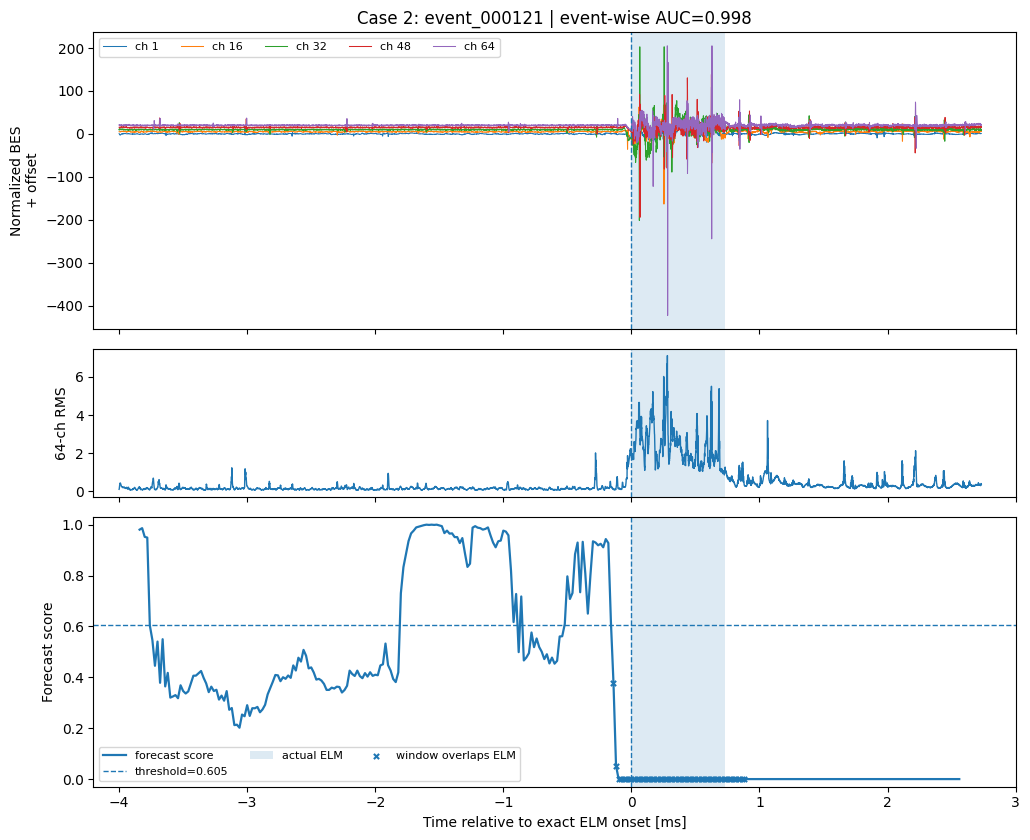

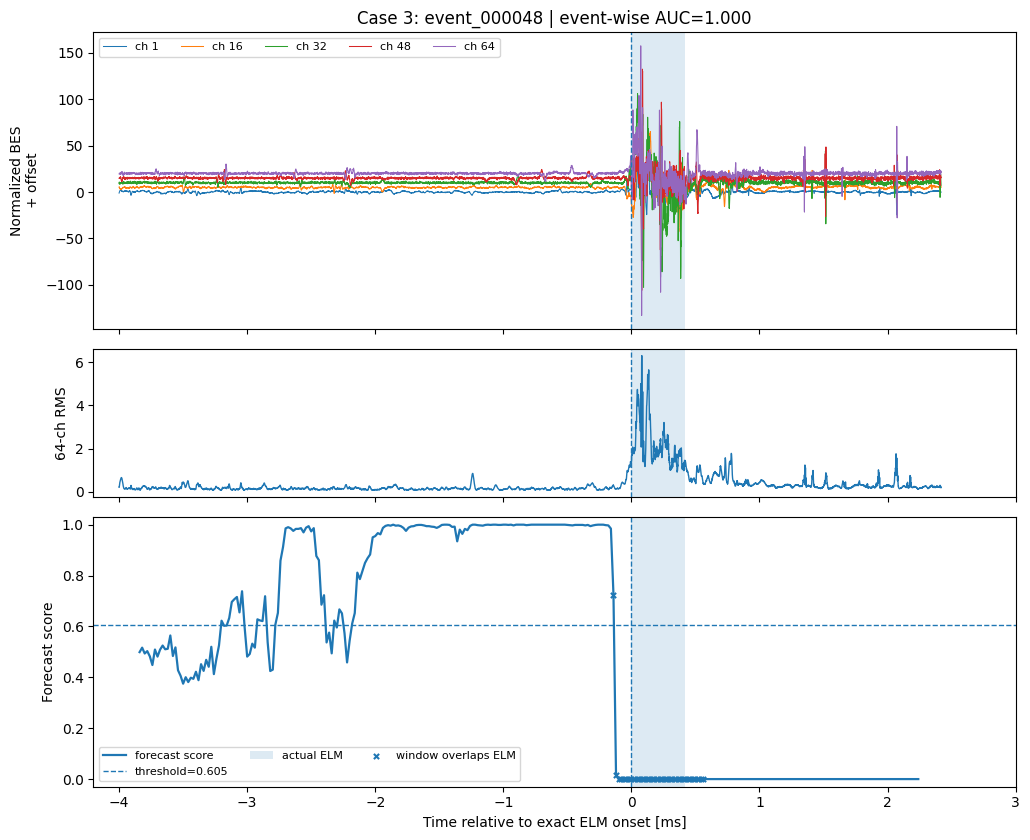

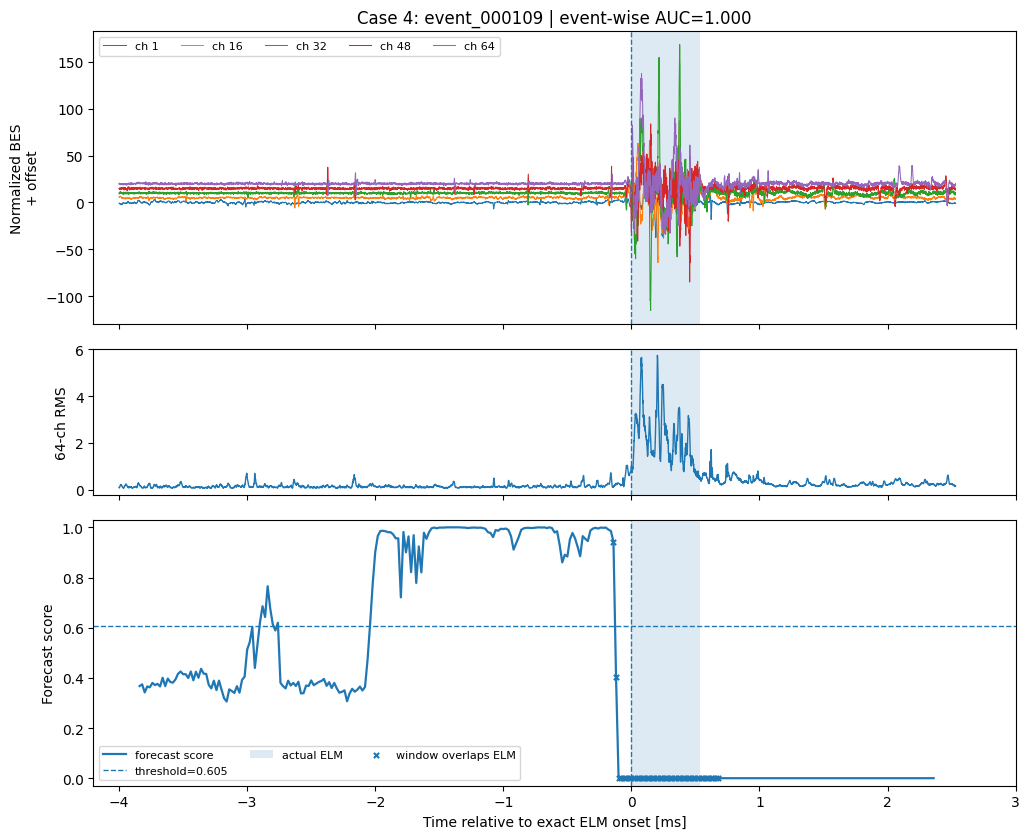

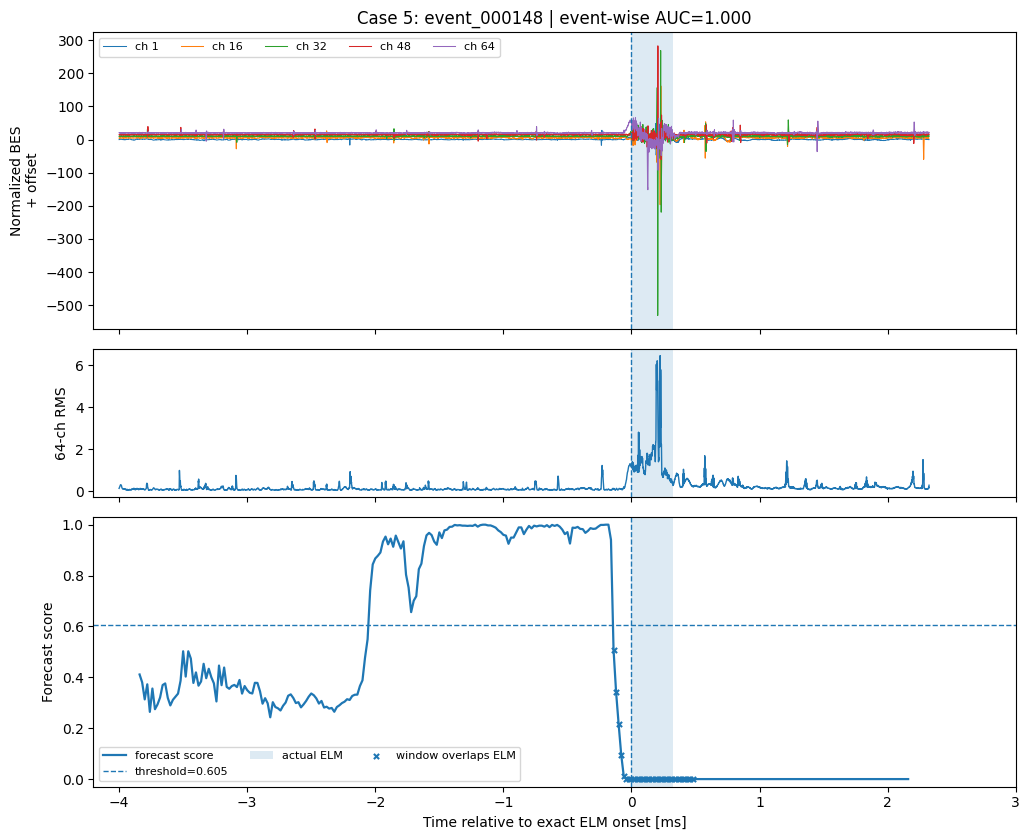

In [9]:
REPRESENTATIVE_CHANNELS_1BASED = [1, 16, 32, 48, 64]


def robust_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    scale = 1.4826 * np.nanmedian(np.abs(x - med))
    if not np.isfinite(scale) or scale < 1e-12:
        scale = np.nanstd(x)
    if not np.isfinite(scale) or scale < 1e-12:
        scale = 1.0
    return (x - med) / scale


for case_no, event_name in enumerate(selected_event_names, start=1):
    q = qualitative[event_name]
    x = q["input"]
    t = q["time_ms"]
    r = q["result"]
    elm_end_ms = q["elm_end_ms"]

    auc_value = float(
        selected_events.loc[selected_events["event"] == event_name, "auc"].iloc[0]
    )

    fig, axes = plt.subplots(
        3, 1,
        figsize=(10.4, 8.5),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.1, 2.0]},
    )

    # Representative BES channels.
    # Shared input is stored as (T,8,8); flatten spatial pixels to channel 1..64.
    x_ch = x.reshape(x.shape[0], 64)
    ax = axes[0]
    for j, ch in enumerate(REPRESENTATIVE_CHANNELS_1BASED):
        trace = robust_zscore(x_ch[:, ch - 1])
        ax.plot(t, trace + 5.0 * j, lw=0.75, label=f"ch {ch}")
    ax.axvline(0, ls="--", lw=1)
    ax.axvspan(0, elm_end_ms, alpha=0.15)
    ax.set_ylabel("Normalized BES\n+ offset")
    ax.set_title(
        f"Case {case_no}: {event_name} | event-wise AUC={auc_value:.3f}"
    )
    ax.legend(ncol=5, fontsize=8)

    # 64-channel RMS.
    ax = axes[1]
    rms = np.sqrt(np.mean(np.asarray(x, dtype=np.float64) ** 2, axis=(1, 2)))
    ax.plot(t, rms, lw=1)
    ax.axvline(0, ls="--", lw=1)
    ax.axvspan(0, elm_end_ms, alpha=0.15)
    ax.set_ylabel("64-ch RMS")

    # Forecast score.
    ax = axes[2]
    score_t = r["dt_from_elm_onset_ms"].to_numpy()
    score = r["score"].to_numpy()
    ax.plot(score_t, score, lw=1.6, label="forecast score")
    ax.axhline(
        DECISION_THRESHOLD,
        ls="--",
        lw=1,
        label=f"threshold={DECISION_THRESHOLD:.3f}",
    )
    ax.axvline(0, ls="--", lw=1)
    ax.axvspan(0, elm_end_ms, alpha=0.15, label="actual ELM")

    ood = r["window_overlaps_actual_elm"].to_numpy(dtype=bool)
    if np.any(ood):
        ax.scatter(
            score_t[ood],
            score[ood],
            s=14,
            marker="x",
            label="window overlaps ELM",
        )

    ax.set_xlabel("Time relative to exact ELM onset [ms]")
    ax.set_ylabel("Forecast score")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(ncol=3, fontsize=8)

    axes[-1].set_xlim(-4.2, max(3.0, elm_end_ms + 2.0))
    fig.tight_layout()
    fig.savefig(
        OUT_DIR / f"qualitative_case_{case_no:02d}_{event_name}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 9. Compact 5-case forecast overview

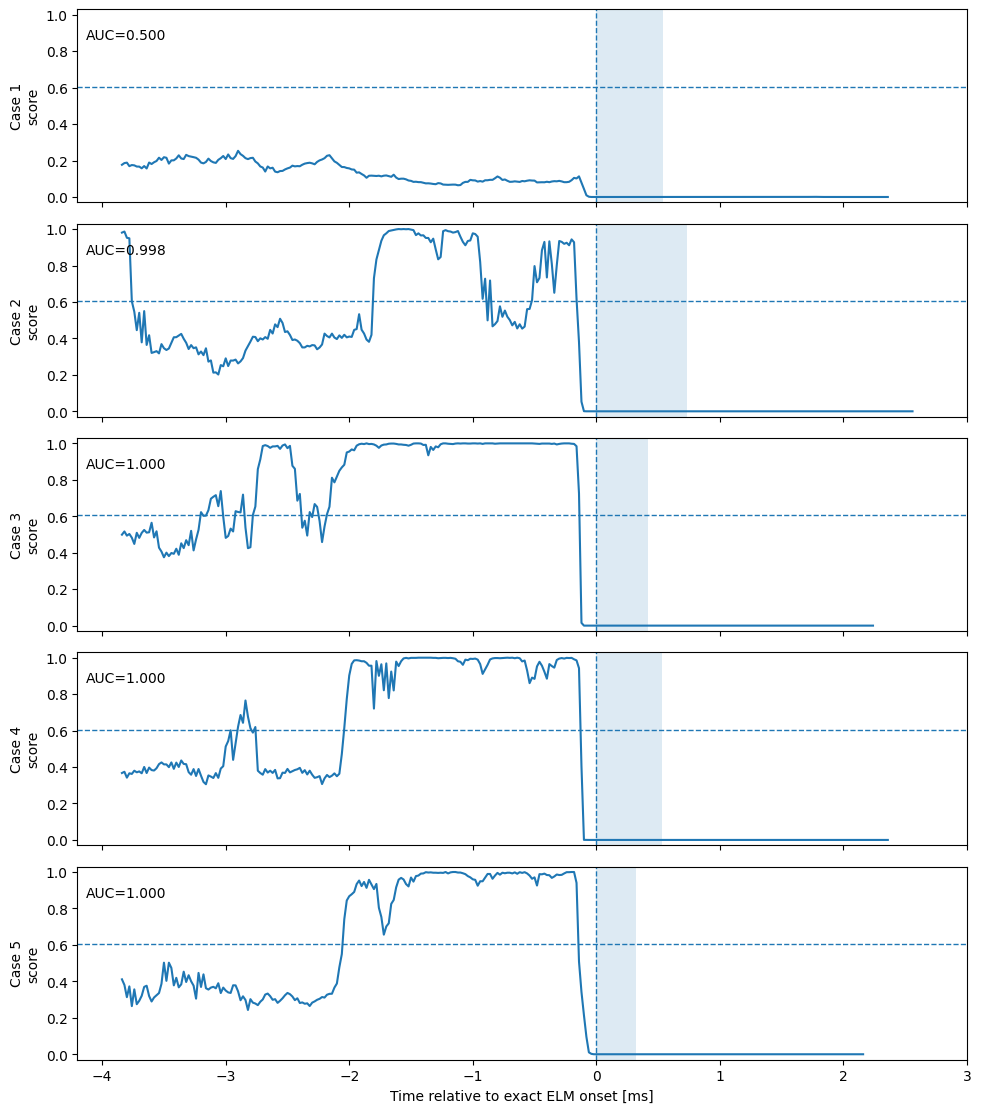

In [10]:
fig, axes = plt.subplots(
    len(selected_event_names), 1,
    figsize=(10, 2.25 * len(selected_event_names)),
    sharex=True,
    sharey=True,
)

if len(selected_event_names) == 1:
    axes = [axes]

for i, (ax, event_name) in enumerate(zip(axes, selected_event_names), start=1):
    q = qualitative[event_name]
    r = q["result"]
    auc_value = float(
        selected_events.loc[selected_events["event"] == event_name, "auc"].iloc[0]
    )

    ax.plot(
        r["dt_from_elm_onset_ms"],
        r["score"],
        lw=1.5,
    )
    ax.axhline(DECISION_THRESHOLD, ls="--", lw=1)
    ax.axvline(0, ls="--", lw=1)
    ax.axvspan(0, q["elm_end_ms"], alpha=0.15)
    ax.set_ylabel(f"Case {i}\nscore")
    ax.set_ylim(-0.03, 1.03)
    ax.text(
        0.01, 0.90,
        f"AUC={auc_value:.3f}",
        transform=ax.transAxes,
        va="top",
    )

axes[-1].set_xlim(-4.2, 3.0)
axes[-1].set_xlabel("Time relative to exact ELM onset [ms]")
fig.tight_layout()
fig.savefig(
    OUT_DIR / "qualitative_5case_forecast_overview.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 10. Forecast-score distributions by phase

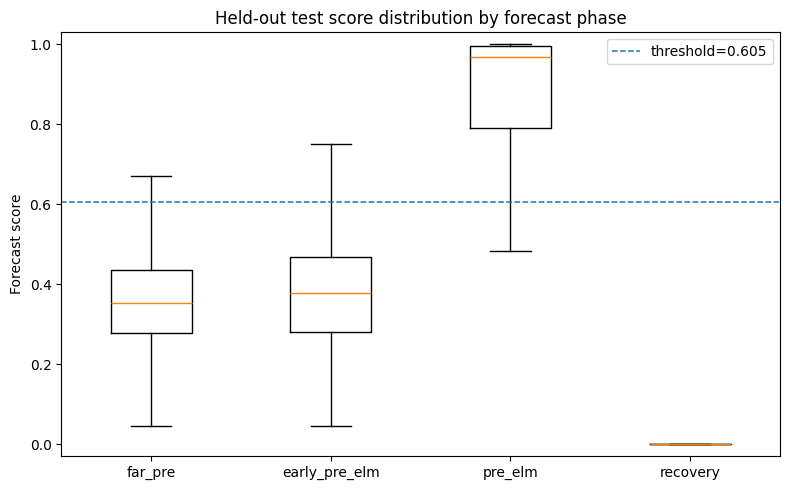

,count,mean,std,median,min,max
range_name,,,,,,
far_pre,4800,0.3686,0.1667,0.3540,0.0396,0.9922
early_pre_elm,9600,0.3843,0.1698,0.3784,0.0464,0.9941
pre_elm,9600,0.8239,0.2751,0.9678,0.0659,1.0000
recovery,4800,0.0019,0.0160,0.0000,0.0000,0.3936


In [11]:
range_order = ["far_pre", "early_pre_elm", "pre_elm", "recovery"]
present = [r for r in range_order if r in set(test_df["range_name"])]

groups = [
    test_df.loc[test_df["range_name"] == r, "score"].to_numpy()
    for r in present
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(groups, tick_labels=present, showfliers=False)
ax.axhline(
    DECISION_THRESHOLD,
    ls="--",
    lw=1.1,
    label=f"threshold={DECISION_THRESHOLD:.3f}",
)
ax.set_ylabel("Forecast score")
ax.set_ylim(-0.03, 1.03)
ax.set_title("Held-out test score distribution by forecast phase")
ax.legend()
fig.tight_layout()
fig.savefig(
    OUT_DIR / "score_distribution_by_phase.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

phase_summary = (
    test_df.groupby("range_name")["score"]
    .agg(["count", "mean", "std", "median", "min", "max"])
)
display(phase_summary.loc[present].round(4))
phase_summary.to_csv(OUT_DIR / "score_distribution_by_phase.csv")

## 11. Consolidated summary

In [12]:
summary = {
    "data_file": DATA_PATH.name,
    "checkpoint": CHECKPOINT_PATH.name,
    "validation_auc": float(val_auc),
    "test_auc": float(test_auc),
    "decision_threshold": float(DECISION_THRESHOLD),
    "test_event_auc_mean": float(event_metrics["auc"].mean()),
    "test_event_auc_median": float(event_metrics["auc"].median()),
    "test_event_auc_std": float(event_metrics["auc"].std()),
    "test_metrics": test_metrics,
    "representative_events": selected_event_names,
}

(OUT_DIR / "evaluation_summary.json").write_text(
    json.dumps(summary, indent=2)
)

display(pd.DataFrame([{
    "validation_auc": val_auc,
    "test_auc": test_auc,
    "event_auc_mean": event_metrics["auc"].mean(),
    "event_auc_median": event_metrics["auc"].median(),
    "accuracy": test_metrics["accuracy"],
    "balanced_accuracy": test_metrics["balanced_accuracy"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "specificity": test_metrics["specificity"],
    "f1": test_metrics["f1"],
}]).round(4))

print("All inference/evaluation outputs:", OUT_DIR)

,validation_auc,test_auc,event_auc_mean,event_auc_median,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,0.9442,0.9387,0.9761,1.0,0.8928,0.8928,0.9514,0.8279,0.9577,0.8854


All inference/evaluation outputs: /global/cfs/cdirs/m3586/sjoung/synthetic_bes_v3_1_elm_ddp/inference_results
